In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [114]:
df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original[df_original['chain_size'] == 0]

In [7]:
len(df['smiles_A'].drop_duplicates())/len(df['smiles_A'])

1.0

In [11]:
1 - df['smiles_A'].drop_duplicates().isin(df_original['smiles_A']).sum()/len(df['smiles_A'].drop_duplicates())

np.float64(0.863013698630137)

In [15]:
df

,smiles_A,static_polarizability,static_polarizability_pred,static_polarizability_original,static_polarizability_pred_original,error
0,C=CC(=O)O,0.000000,0.020411,27.820679,43.747154,0.572469
1,C=CC(=O)[O-1].[NH4+1],0.005025,0.046444,31.741656,64.059746,1.018160
2,COC(=O)/C=C/C1=CC=CC=N1,0.010050,0.081201,35.662634,91.179620,1.556727
3,COC(=O)/C=C/C1=CC=CS1,0.010050,0.072004,35.662634,84.003624,1.355508
4,COC(=O)/C=C/C1=NC=CC=N1,0.010050,0.073421,35.662634,85.108980,1.386503
...,...,...,...,...,...,...
652,CCOC(=O)C=CC1=CC=C(C=C1)OC2C3=CC=CC=C3OCO2,0.994975,0.168631,804.174172,159.399410,0.801785
653,CCOC(=O)C=CC1=CC=C(C(=C1)C)OCC2=CC=CC=C2[N+1](...,0.994975,0.179760,804.174172,168.082750,0.790987
654,C=CC(=O)OCC(CO)(COCC(COC(=O)C=C)(COC(=O)C=C)CO...,1.000000,0.095538,808.095149,102.366394,0.873324
655,C=CC(=O)OCC(CO)COCC(COC(=O)C=C)(COC(=O)C=C)COC...,1.000000,0.192269,808.095149,177.843060,0.779923


In [21]:
195/200

0.975

In [20]:
df_grouped = df.groupby('static_polarizability').count()['smiles_A'].reset_index()
df_grouped

,static_polarizability,smiles_A
0,0.000000,1
1,0.005025,1
2,0.010050,3
3,0.015075,2
4,0.020101,3
...,...,...
190,0.979899,1
191,0.984925,5
192,0.989950,5
193,0.994975,4


In [29]:
polarizability_series = pd.Series(np.linspace(0,1,200)).round(4)

In [30]:
polarizability_series

0      0.0000
1      0.0050
2      0.0101
3      0.0151
4      0.0201
        ...  
195    0.9799
196    0.9849
197    0.9899
198    0.9950
199    1.0000
Length: 200, dtype: float64

In [34]:
polarizability_series[~polarizability_series.isin(df['static_polarizability'].round(4))].values

array([0.0804, 0.5578, 0.5678, 0.6884, 0.8191])

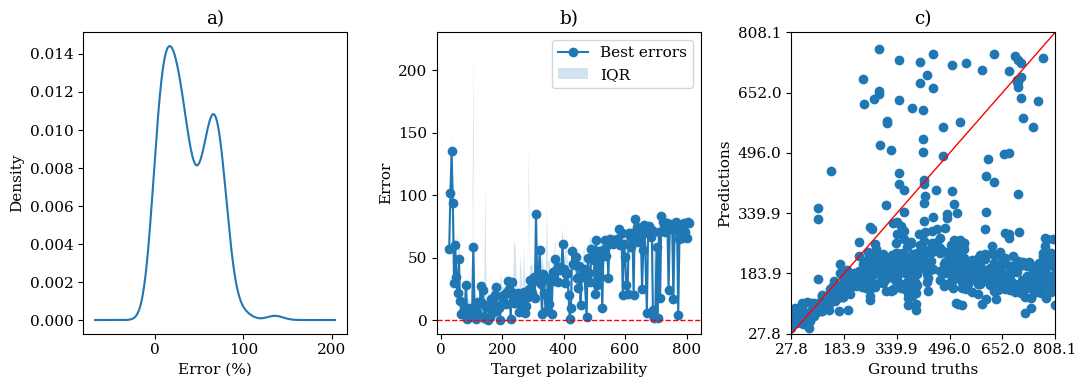

In [143]:
fig = plt.figure(figsize=(11,4))

df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df['error'] = abs(100*df['error'])

df_grouped = df.groupby(['static_polarizability_original']).min()
best_fitness = df.groupby("static_polarizability_original")["error"].min()
q1 = df.groupby("static_polarizability_original")["error"].quantile(0.25)
q3 = df.groupby("static_polarizability_original")["error"].quantile(0.75)
targets_sorted = sorted(df["static_polarizability_original"].unique())

plt.subplot(1,3,1)
df_grouped['error'].plot.kde()
plt.xlabel('Error (%)')
plt.title('a)')

plt.subplot(1,3,2)
plt.plot(targets_sorted, best_fitness.loc[targets_sorted], marker="o", label="Best errors")
plt.fill_between(targets_sorted, q1.loc[targets_sorted], q3.loc[targets_sorted], alpha=0.2, label="IQR")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Target polarizability")
plt.ylabel("Error")
plt.title("b)")
plt.legend()

targets_expanded = df["static_polarizability_original"]  # placeholder
pred = df["static_polarizability_pred_original"]

plt.subplot(1,3,3)
plt.scatter(targets_expanded, pred)
plt.plot([targets_expanded.min(), targets_expanded.max()], [targets_expanded.min(), targets_expanded.max()], "r", linewidth=1)
plt.xlim([targets_expanded.min(), targets_expanded.max()])
plt.ylim([targets_expanded.min(), targets_expanded.max()])
plt.xticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.yticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.xlabel("Ground truths")
plt.ylabel("Predictions")
plt.title("c)")

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_22.pdf')

-1.0532450398261206


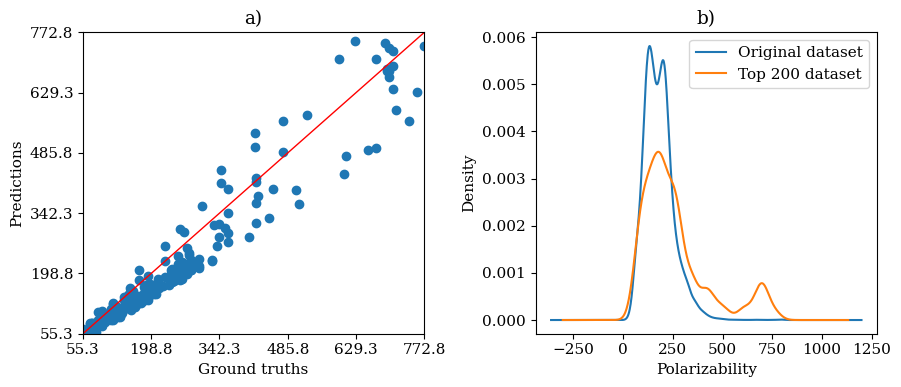

0.8975652339674782


In [142]:
from sklearn.metrics import r2_score

print(r2_score(df['static_polarizability_original'], df['static_polarizability_pred_original']))

fig = plt.figure(figsize=(9,4))

df_aux = df[df['error'] <= 35].sort_values(by='error')[:200]

targets_expanded = df_aux["static_polarizability_original"]  # placeholder
pred = df_aux["static_polarizability_pred_original"]

plt.subplot(1,2,1)
plt.scatter(targets_expanded, pred)
plt.plot([targets_expanded.min(), targets_expanded.max()], [targets_expanded.min(), targets_expanded.max()], "r", linewidth=1)
plt.xlim([targets_expanded.min(), targets_expanded.max()])
plt.ylim([targets_expanded.min(), targets_expanded.max()])
plt.xticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.yticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.xlabel("Ground truths")
plt.ylabel("Predictions")
plt.title("a)")

plt.subplot(1,2,2)
df_original['static_polarizability'].plot.kde(bw_method=0.18)
df_aux['static_polarizability_original'].plot.kde(bw_method=0.18)
plt.xlabel('Polarizability')
plt.ylabel('Density')
plt.legend(['Original dataset', 'Top 200 dataset'])
plt.title("b)")

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_23.pdf')
print(r2_score(df_aux['static_polarizability_original'], df_aux['static_polarizability_pred_original']))